In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture


In [53]:
data_path = r"C:\Users\lanph\OneDrive\Desktop\Introduction to Data Science\Final_Project\Adult_Project_Final_Term\data\raw\adult.csv"
df = pd.read_csv(data_path)




In [54]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [55]:
save_figure_path =  r"C:\Users\lanph\OneDrive\Desktop\Introduction to Data Science\Final_Project\Adult_Project_Final_Term\reports\figures"
import os 

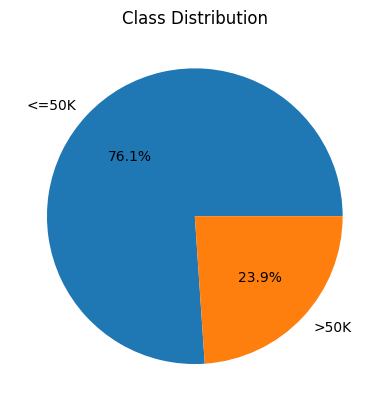

In [56]:
df["income"] = df["income"].str.strip()
df["income"] = df["income"].str.replace(".", "", regex=False)
class_counts = df['income'].value_counts()   
labels = class_counts.index
sizes = class_counts.values
plt.figure()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Class Distribution')
plt.savefig(os.path.join(save_figure_path, "class_distribution.png"))
plt.show()

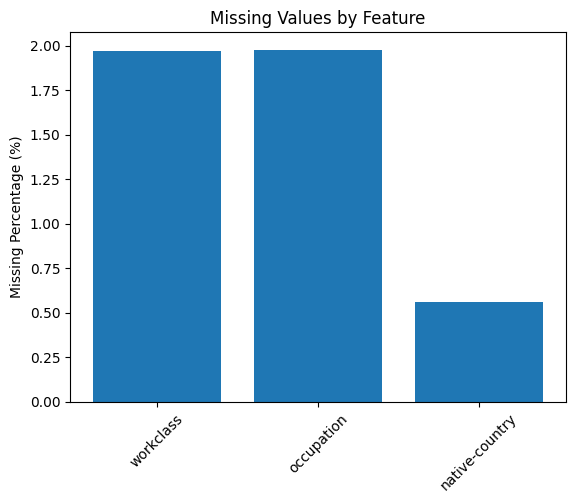

In [57]:
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0]  

plt.figure()
plt.bar(missing_pct.index, missing_pct.values)

plt.title('Missing Values by Feature')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45)
plt.savefig(os.path.join(save_figure_path, "missing_values.png"))
plt.show()

In [58]:
df_clean = df.copy()
missing_category = ["workclass", "occupation", "native-country"]
for category in missing_category: 
    df_clean[category] = df_clean[category].fillna(df_clean[category].mode()[0])
df_clean.isnull().sum() 
    

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [59]:
df_clean.isnull().sum()   

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [60]:
df_clean.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


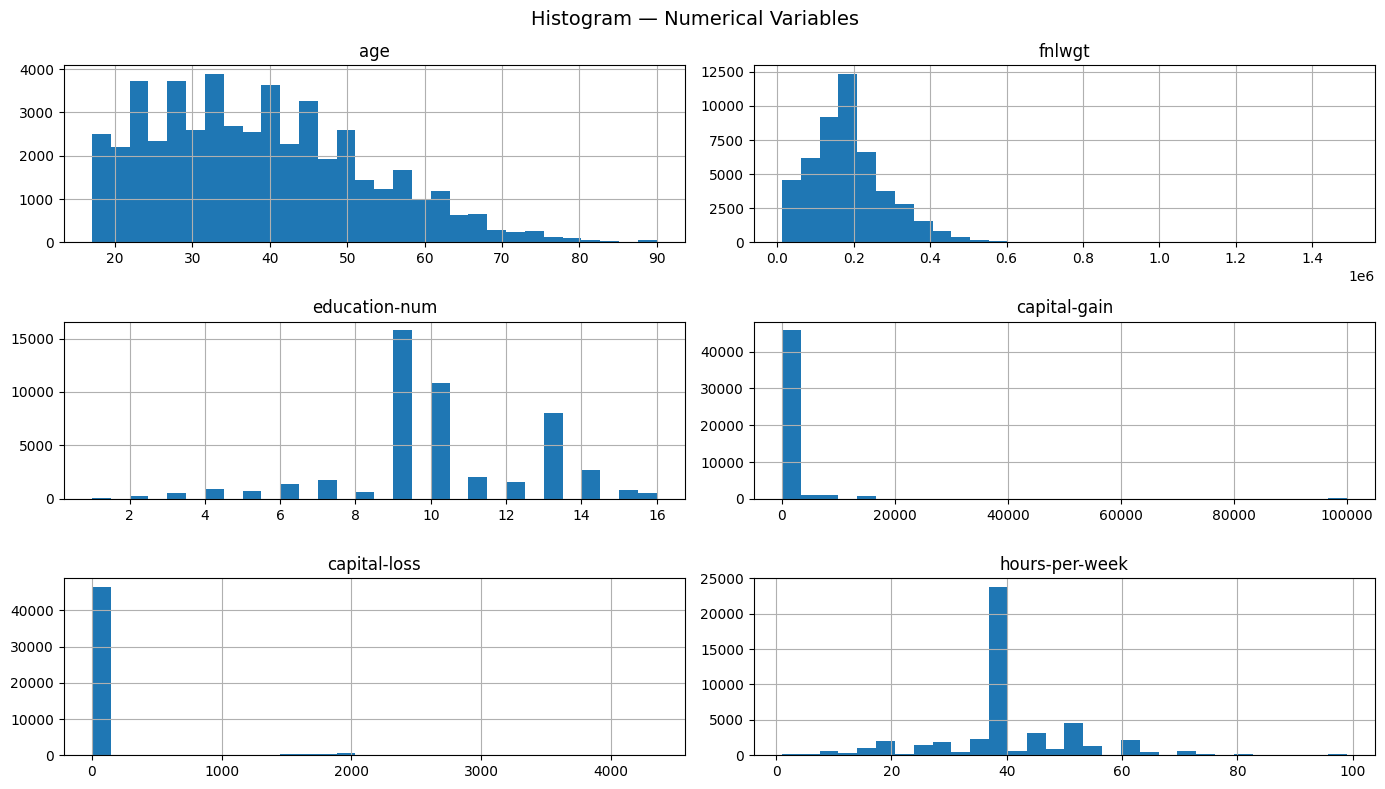

In [61]:

# --- Histogram các biến số ---
num_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
df_clean[num_cols].hist(bins=30, figsize=(14, 8))
plt.suptitle("Histogram — Numerical Variables", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(save_figure_path, "numerical_histograms.png"))
plt.show()

Chọn thuật toán nào? Nếu dữ liệu có quá nhiều biến bị lệch, zero-inflated, và nhiều outlier -> Các mô hình Tree-based (XGBoost, Random Forest) nên là ưu tiên số 1 vì không mất công xử lý.

Làm Feature Engineering thế nào? Giúp  biết chính xác cột nào cần Log Transform, cột nào cần chia Bin (nhóm tuổi, nhóm giờ làm), cột nào cần đặt Cờ (Flag) để "mớm" thông tin tốt nhất cho mô hình học ranh giới phân loại.

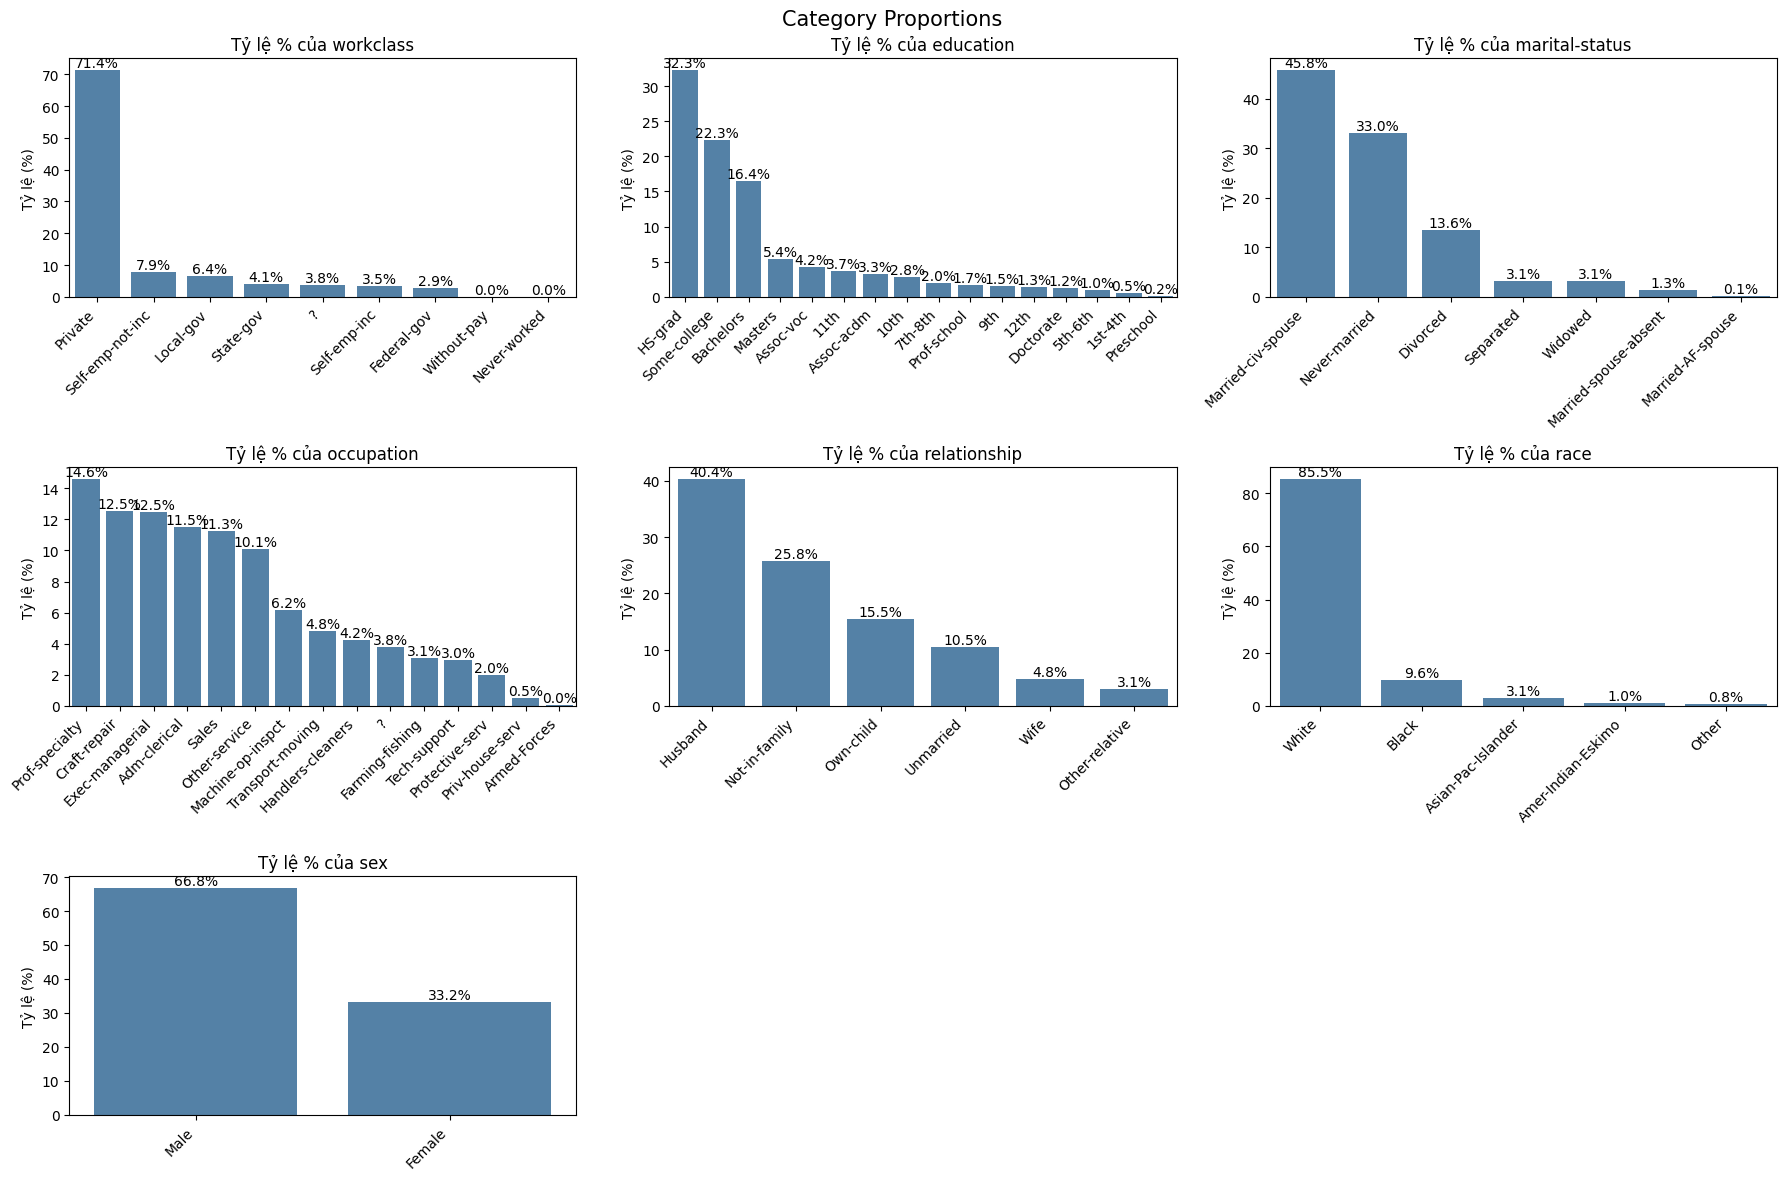

In [62]:

plt.figure(figsize=(18, 12))
cat_cols = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex']
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    
    # Tính tỷ lệ phần trăm cho từng category trong cột
    prop_df = df_clean[col].value_counts(normalize=True).reset_index()
    prop_df.columns = [col, 'percentage']
    prop_df['percentage'] = prop_df['percentage'] * 100 # Đổi ra %
    
    # Vẽ barplot
    ax = sns.barplot(data=prop_df, x=col, y='percentage', color='steelblue')
    
    # Gắn text % lên đỉnh mỗi cột để dễ quan sát
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.1f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10)
    
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Tỷ lệ % của {col}')
    plt.ylabel('Tỷ lệ (%)')
    plt.xlabel('') 

plt.suptitle("Category Proportions", fontsize=15)
plt.tight_layout()
plt.savefig(os.path.join(save_figure_path, "categorical_proportions.png"))  
plt.show()

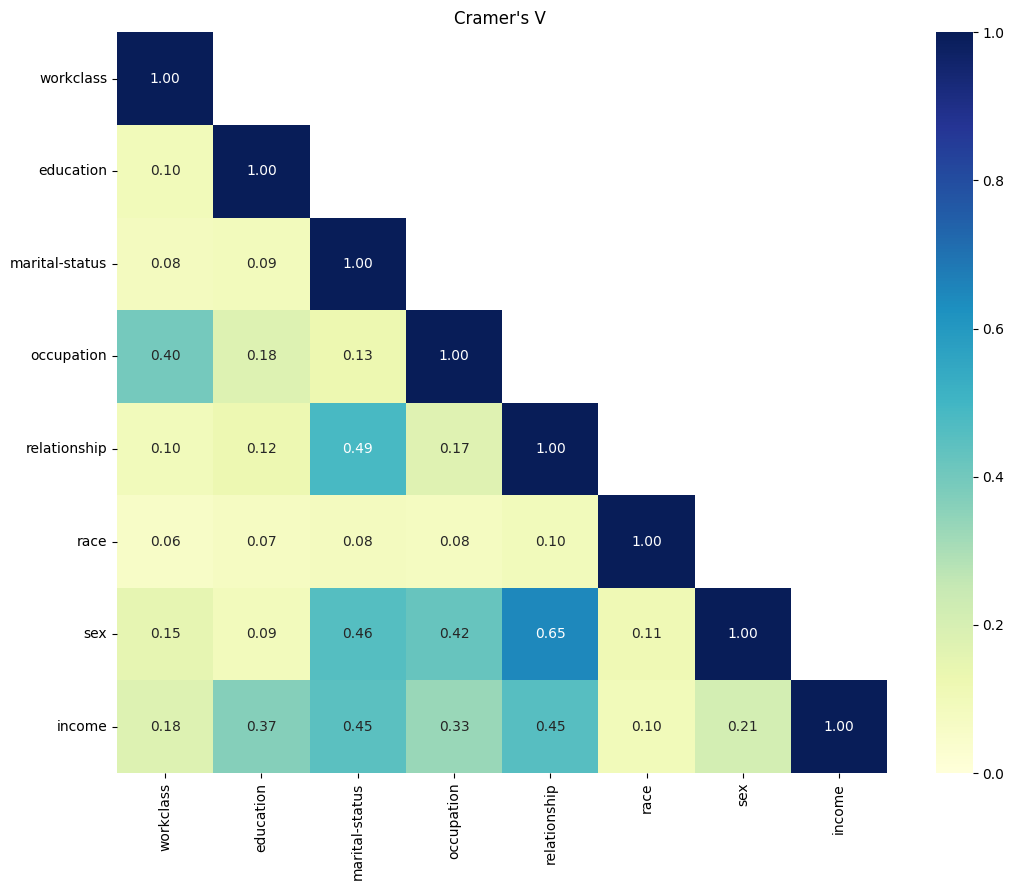

In [63]:
# --- Cramer's V — biến phân loại (bao gồm cả income) ---
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2_stat, _, _, _ = chi2_contingency(confusion_matrix)
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    if min(r, k) <= 1:
        return 0.0
    return np.sqrt(chi2_stat / (n * (min(r, k) - 1)))
# [FIX] Dùng cat_cols đã loại 'income' → ma trận vuông 7×7 không lẫn target
# Để thấy mức liên kết với income, thêm income vào riêng cho heatmap
cramer_cols = cat_cols + ['income']
cv_matrix = pd.DataFrame(index=cramer_cols, columns=cramer_cols, dtype=float)

for col1 in cramer_cols:
    for col2 in cramer_cols:
        cv_matrix.loc[col1, col2] = cramers_v(df_clean[col1], df_clean[col2])

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(cv_matrix, dtype=bool), k=1)  # chỉ hiện tam giác dưới
sns.heatmap(cv_matrix, annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1, mask=mask)
plt.title("Cramer's V ")
plt.tight_layout()
plt.savefig(os.path.join(save_figure_path, "cramers_v_heatmap.png"))    
plt.show()


Linear Models (Logistic Regression, SVM): Rất "sợ" sự tương quan giữa các biến độc lập (như cặp sex và relationship). Đa cộng tuyến làm cho các trọng số (weights) của mô hình bị nhiễu, kém ổn định và có thể dẫn đến hiện tượng Overfitting. Dựa vào ma trận này, bạn nên xem xét loại bỏ 1 trong 2 biến có tương quan cao với nhau trước khi train Logistic Regression. Hoặc dùng chuẩn L1 hoặc  L2. 

Tree-based Models (Decision Tree, Random Forest, XGBoost): Các mô hình cây khá gần như miễn nhiễm với đa cộng tuyến về mặt hiệu suất phân loại (Accuracy, F1-Score không bị giảm). Tuy nhiên, nó sẽ phá hỏng bảng Feature Importance. Thay vì dồn điểm quan trọng cho 1 biến, cây sẽ chia sẻ điểm đó cho cả sex và relationship, làm cho cả 2 biến trông có vẻ ít quan trọng hơn giá trị thực của chúng.

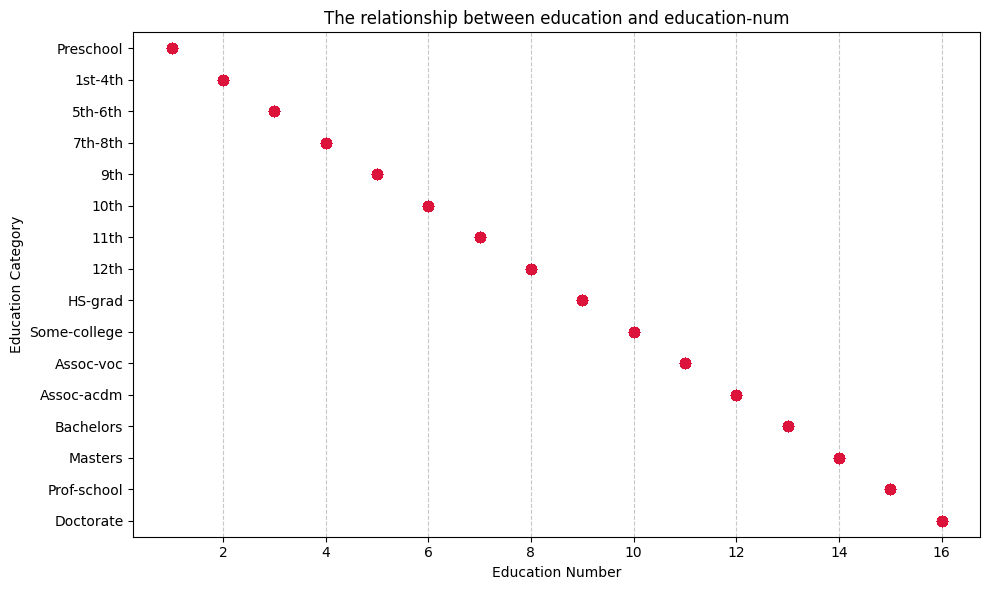

In [64]:
plt.figure(figsize=(10, 6))
# Sắp xếp trục y theo education-num cho đẹp mắt
order = df.groupby('education')['education-num'].mean().sort_values().index

sns.stripplot(data=df, x='education-num', y='education', order=order, 
              jitter=False, size=8, color='crimson')

plt.title("The relationship between education and education-num")
plt.xlabel("Education Number")
plt.ylabel("Education Category")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(save_figure_path, "education_vs_education_num.png"))
plt.show()

In [66]:
df_clean_ =df_clean.drop(columns=["fnlwgt", "education"])    
df_clean_.info() 


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   education-num   48842 non-null  int64 
 3   marital-status  48842 non-null  object
 4   occupation      48842 non-null  object
 5   relationship    48842 non-null  object
 6   race            48842 non-null  object
 7   sex             48842 non-null  object
 8   capital-gain    48842 non-null  int64 
 9   capital-loss    48842 non-null  int64 
 10  hours-per-week  48842 non-null  int64 
 11  native-country  48842 non-null  object
 12  income          48842 non-null  object
dtypes: int64(5), object(8)
memory usage: 4.8+ MB


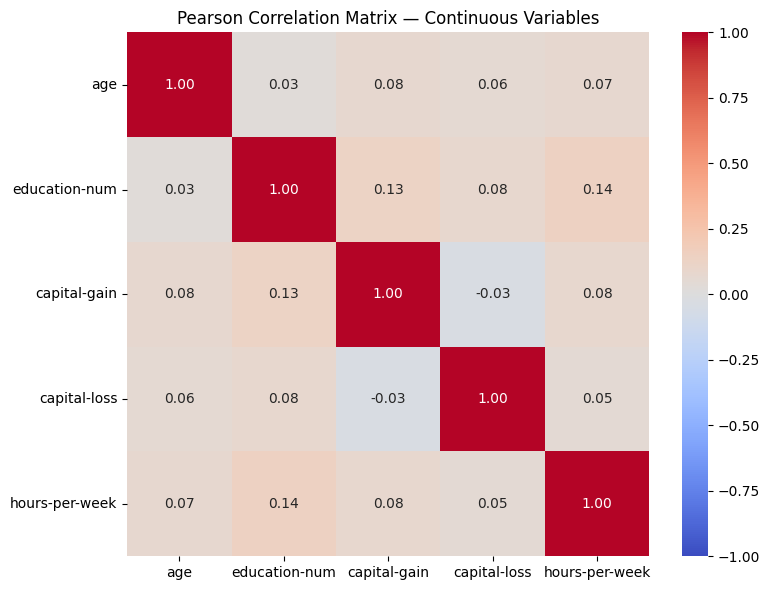

In [68]:

plt.figure(figsize=(8, 6))
num_cols = df_clean_.select_dtypes(include=["int64", "float64"]).columns
corr = df_clean_[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Pearson Correlation Matrix — Continuous Variables")
plt.tight_layout()
plt.savefig(os.path.join(save_figure_path, "pearson_correlation.png"))
plt.show()

In [71]:
df_clean_.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   education-num   48842 non-null  int64 
 3   marital-status  48842 non-null  object
 4   occupation      48842 non-null  object
 5   relationship    48842 non-null  object
 6   race            48842 non-null  object
 7   sex             48842 non-null  object
 8   capital-gain    48842 non-null  int64 
 9   capital-loss    48842 non-null  int64 
 10  hours-per-week  48842 non-null  int64 
 11  native-country  48842 non-null  object
 12  income          48842 non-null  object
dtypes: int64(5), object(8)
memory usage: 4.8+ MB


In [19]:
df_clean_.to_csv(os.path.join( r"C:\Users\lanph\OneDrive\Desktop\Introduction to Data Science\Final_Project\Adult_Project_Final_Term\data\processed\adult_after_eda.csv"), index=False) 
 
df_mapping_native_country = pd.read_csv(r"C:\Users\lanph\OneDrive\Desktop\Introduction to Data Science\Final_Project\Adult_Project_Final_Term\data\processed\mapping_.csv")
df_mapping_native_country.describe()

,country_adult_dataset,income_group
count,42,42
unique,42,4
top,United-States,H
freq,1,14
